### Quickstart

Let's first grab some example data from the GitHub repository:

In [2]:
import numpy as np
import requests, io
import matplotlib.pyplot as plt

response = requests.get(
    'https://github.com/TutteInstitute/temporal-mapper/raw/refs/heads/release/docs/data/mapper_demo_data.npy'
)
data = np.load(io.BytesIO(response.content))
print(data.shape)

(23000, 2)


We'll use projection to the $x$-axis as our Morse-type function, and a sklearn clusterer to do single-linkage clustering. Here's how you fit a TemporalMapper:

In [3]:
import temporalmapper as tm 
from sklearn.cluster import AgglomerativeClustering

## Single-linkage clustering
clusterer = AgglomerativeClustering(
    linkage = "single",
    distance_threshold = 0.25,
    n_clusters = None,
)

mapper = tm.TemporalMapper(
    data[:,0],
    data[:,1],
    clusterer,
    N_checkpoints = 10
)
mapper.fit()



,time,"array([-2.990...hape=(23000,))"
,data,"array([[ 0.65...pe=(23000, 1))"
,clusterer,Agglomerative...clusters=None)
,N_checkpoints,10
,neighbours,50
,overlap,0.5
,inclusion_threshold,0.01
,checkpoints,array([-2.621... 2.63526407])
,show_outliers,False
,slice_method,'time'
,rate_sensitivity,1


The output of Mapper is a directed graph; you can access the graph as a NetworkX object via `TemporalMapper.G`:

In [4]:
mapper.G

You can also plot the graph using `TemporalMapper.temporal_plot`; here since our graph is so simple, we will set `layout_optimization='none'`.

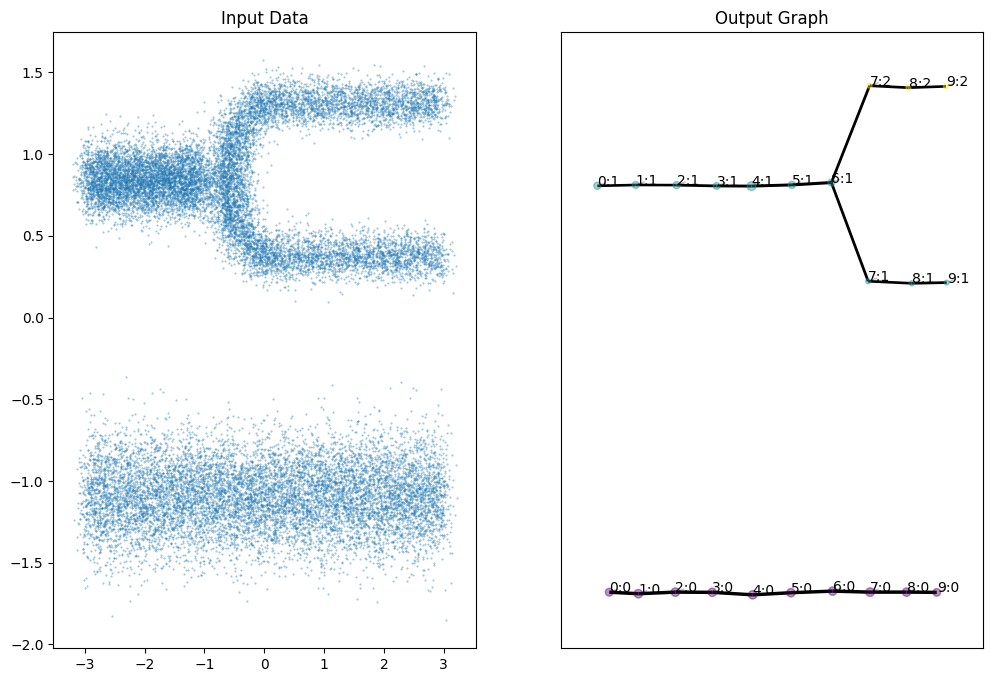

In [5]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,8))
ax1.set_title("Input Data")
ax1.scatter(
    data[:,0], data[:,1], s=0.2, alpha=0.5
)
ax2.set_title("Output Graph")
ax2 = mapper.temporal_plot(ax=ax2, layout_optimization='none')
plt.show()

If you have Plotly installed, you can also get an interactive HTML/JS plot:

In [ ]:
mapper.interactive_temporal_plot(layout_optimization='none')